In [124]:
import os
import pandas as pd
import geopandas as gpd
import rasterio
import re
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [125]:
# user-defined paths
base_dir = '../../../../datos-notebooks/3.global-data-cba/'
ground_data_name = 'ground_data_170226_validation_TAcorr.gpkg'
mrt_name = 'MRT_1m-15dif_distedif.tif' 

# derived paths
ground_data_path = os.path.join(base_dir, 'MRT-prediction/ground_data', ground_data_name)
mrt_path = os.path.join(base_dir, 'MRT-prediction', mrt_name)

#### reading and calibrating ground data 

In [126]:
gdf = gpd.read_file(ground_data_path)

C:\Users\guada\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pyogrio\raw.py:198: RuntimeWarning:

Non-conformant content for record 1 in column start, 2026-02-17T13:18:53.548-03:00, successfully parsed



In [127]:
# calibrate TG1
# from notebook 3.4.4.1. 
gdf["tg_corr"] = np.where(
    gdf["Instrument"] == "T1 - Sper Scientific 800036 ",
    0.639 * gdf["TG"] + 9.681,   # apply correction for T1
    gdf["TG"]                    # keep original value for T2
)

In [128]:
# calibrate wind speed
# from notebook 3.4.4.2.

t1 = gdf[gdf["Instrument"] == "T1 - Sper Scientific 800036 "]["WIND M/S"]
t2 = gdf[gdf["Instrument"] == "T2 - TM-188D TENMARS "]["WIND M/S"]

t1_min, t1_max = t1.min(), t1.max()
t2_min, t2_max = t2.min(), t2.max()

gdf.loc[gdf["Instrument"] == "T2 - TM-188D TENMARS ", "wind_norm"] = \
    t1_min + (t2 - t2_min) / (t2_max - t2_min) * (t1_max - t1_min)

# T1 queda igual
gdf.loc[gdf["Instrument"] == "T1 - Sper Scientific 800036 ", "wind_norm"] = t1.values


In [129]:
# compute mean of wind values
# because wind recorded is instantaneous, but TG is affected by wind conditions in the minutes before measurement


gdf["end"] = pd.to_datetime(gdf["end"], errors="coerce")

gdf = gdf.sort_values("end") # Sort by time
gdf = gdf.set_index("end") # Set as index

gdf["wind_mean"] = (
    gdf["wind_norm"]
    .rolling(window="10min", center=True, min_periods=1)
    .mean()
    .rolling(window="10min", center=True, min_periods=1)
    .mean()
    .round(2)
)


gdf = gdf.reset_index()

#### computing observed MRT and extracting predicted MRT values for ground data

In [130]:
# Parameters
eps = 0.95
D1 = 0.04   # diameter of globe 1 [m] 
D2 = 0.05  # diameter of globe 2 [m] 

# Select diameter according to instrument
D = np.where(gdf["Instrument"] == "T1 - Sper Scientific 800036 ", D1,D2)

# MRT calculation using row-specific diameter
gdf["MRT"] = (
    (
        (gdf["tg_corr"] + 273.15)**4
        + (1.1e8 * gdf["wind_mean"]**0.6 / (eps * D2**0.4)) * (gdf["tg_corr"] - gdf["TA"]) # use D2 because TG values are calibrated to Thermometer 2
    )**0.25
    - 273.15
)

In [131]:
# read raster crs and sample values
with rasterio.open(mrt_path) as src:
    mrt_crs = src.crs
    points_proj = gdf.to_crs(mrt_crs)
    samples = list(src.sample(zip(points_proj.geometry.x, points_proj.geometry.y)))
    points_proj['MRT_predicted'] = [s[0] for s in samples]

points_proj['MRT_predicted'] = points_proj['MRT_predicted'].astype(float) 
points_proj["ID"] = range(len(points_proj))

# export gpkg
out_gpkg = os.path.join(base_dir, 'MRT-prediction/MRT_points_2026.gpkg')
points_proj.to_file(out_gpkg, driver="GPKG")


In [132]:
obs = points_proj['MRT']
pred = points_proj['MRT_predicted']
points_proj['residuals'] = obs - pred

#### analysis

In [133]:
# Metrics

residuals = obs - pred

mae = np.mean(np.abs(residuals)).round(2)
rmse = np.sqrt(np.mean(residuals**2)).round(2)
bias = np.mean(residuals).round(2)

print("MAE:", mae)
print("RMSE:", rmse)
print("Bias:", bias)

MAE: 2.46
RMSE: 3.26
Bias: -0.12


In [134]:
# plot

# Scatter
fig = px.scatter(
    points_proj,
    x=points_proj['MRT'],
    y=points_proj['MRT_predicted'],
    color=abs(points_proj['residuals']),
    hover_data=["tg_corr", "TA","wind_mean", "Instrument", "condition", "residuals", "WIND M/S", "context"],
)

# 1:1 line
m = min(obs.min(), pred.min())
M = max(obs.max(), pred.max())

fig.add_scatter(
    x=[m, M],
    y=[m, M],
    mode="lines",
    line=dict(color="black", width=2), 
    name="1:1 line"
)

fig.update_layout(
    xaxis_title="Observed MRT °C",
    yaxis_title="Predicted MRT °C",
    title="observed vs predicted MRT", 
    coloraxis_colorbar=dict(title="Residuals")
)


fig.show()


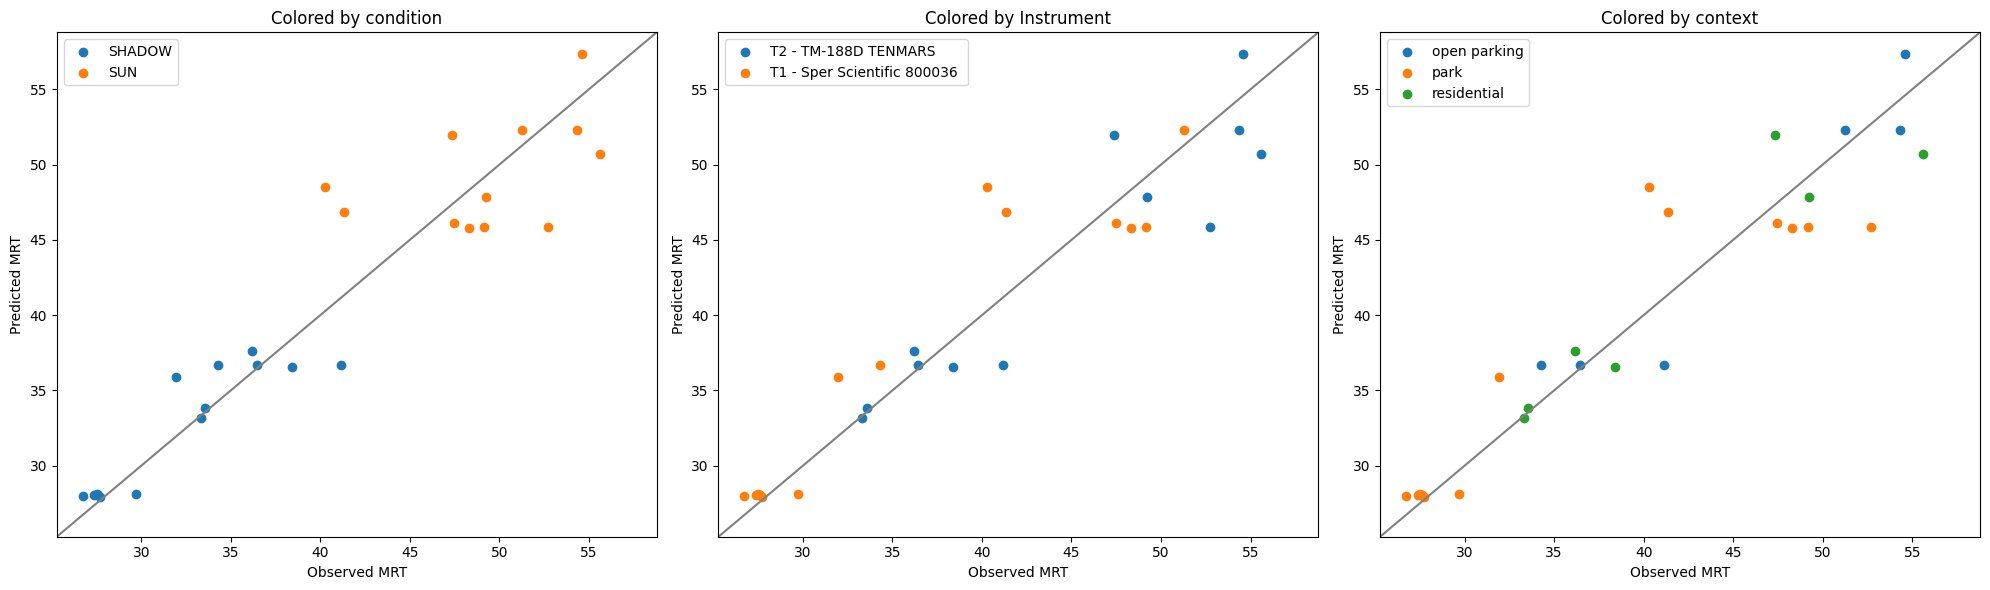

In [135]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Helper values
x = points_proj["MRT"]
y = points_proj["MRT_predicted"]

# 1) condition
for cond in points_proj["condition"].unique():
    mask = points_proj["condition"] == cond
    axes[0].scatter(x[mask], y[mask], label=cond)
axes[0].set_title("Colored by condition")
axes[0].set_xlabel("Observed MRT")
axes[0].set_ylabel("Predicted MRT")
axes[0].legend()


# 2) Instrument
for inst in points_proj["Instrument"].unique():
    mask = points_proj["Instrument"] == inst
    axes[1].scatter(x[mask], y[mask], label=inst)
axes[1].set_title("Colored by Instrument")
axes[1].set_xlabel("Observed MRT")
axes[1].set_ylabel("Predicted MRT")
axes[1].legend()


# 3) context
for ctx in points_proj["context"].unique():
    mask = points_proj["context"] == ctx
    axes[2].scatter(x[mask], y[mask], label=ctx)
axes[2].set_title("Colored by context")
axes[2].set_xlabel("Observed MRT")
axes[2].set_ylabel("Predicted MRT")
axes[2].legend()


# 1:1 reference line
for ax in axes.flat:
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, color="gray")
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()

In [136]:
# Scatter
fig = px.scatter(
    points_proj,
    x=pred,
    y=residuals,
    color="context",
    hover_data=["TG", "TA","wind_mean", "condition", "Instrument", "tg_corr", "MRT"],
)

# 1:1 line
fig.add_scatter(
    x=[pred.min(), pred.max()],
    y=[0, 0],
    mode="lines",
    name="Zero residual line"
)

fig.update_layout(
    xaxis_title="Predicted MRT °C",
    yaxis_title="Residuals (Obs - Pred)",
    title="points_proj residuals"
)

fig.update_yaxes(scaleanchor="x", scaleratio=1)

fig.show()

In [137]:
metrics_residual = (
    points_proj
    .groupby("context")["residuals"]
    .agg(
        mean="mean",
        std="std",
        min="min",
        max="max",
        count="count",
        mae=lambda x: np.mean(np.abs(x)),
        rmse=lambda x: np.sqrt(np.mean(x**2))
    )
)

metrics_residual

,mean,std,min,max,count,mae,rmse
context,,,,,,,
open parking,0.022044,2.773113,-2.711364,4.493031,6,2.151214,2.531590
park,-0.396694,3.908705,-8.233853,6.867457,13,2.811639,3.776256
residential,0.288805,2.941618,-4.598435,4.902050,7,2.074552,2.738679


In [138]:
import plotly.express as px

df_plot = points_proj.drop(columns="geometry")

fig = px.box(
    df_plot,
    x="context",
    y="residuals",
    points="all",
    hover_data=["ID"],
)

fig.add_hline(y=0, line_dash="solid", line_color="black")

fig.update_layout(
    yaxis_title="Residual (obs-pred)",
    xaxis_title="",
    xaxis_tickangle=45
)

fig.update_traces(
    jitter=0,        # 0 = centrado, 1 = disperso
    pointpos=0,      # 0 = dentro de la caja, -1 o 1 = al costado
)
fig.show()

BEFORE STARTING, LOCATION OF SSOME POINTS WAS CORRECTED. SOME OF THEM WERE UNDER TREES NOT DETECTED:ALSO MOVED UNDER A DETECTED TREE.

10 AND 4 ARE OVERESTIMATED IN MODEL BECAUSE THERE IS DETECTED A BUILDING THAT DOESNT EXIST 


<Figure size 800x600 with 0 Axes>

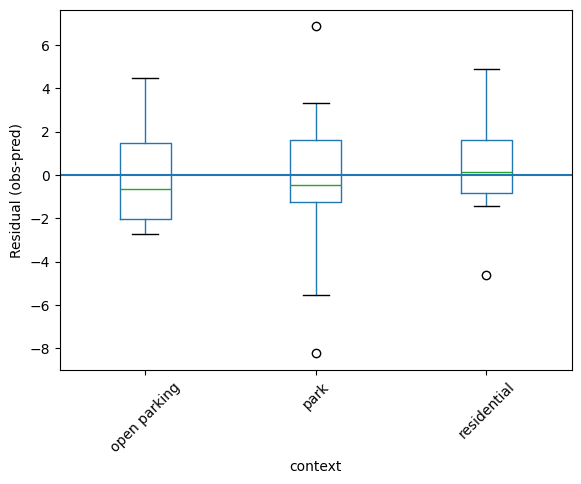

In [139]:
plt.figure(figsize=(8,6))

points_proj.boxplot(
    column="residuals",
    by="context",
    grid=False
)

plt.axhline(0)
plt.ylabel("Residual (obs-pred)")
plt.title("")
plt.suptitle("")

plt.xticks(rotation=45)
plt.show()

From this we can understand the model limitations: It does not account for reflection from nearby objects nor for the different materials.
- in residential areas, where the roadway and nearby houses reflect radiation, the observed values were higher than the predicted ones.
- in open parkings, only the roadway reflects radiation, so the observed values were higher than the predicted ones but lower than in residential areas.
- in parks, where there are no nearby reflective objects, the observed values were lower than the predicted ones.

comparando TA con MRT

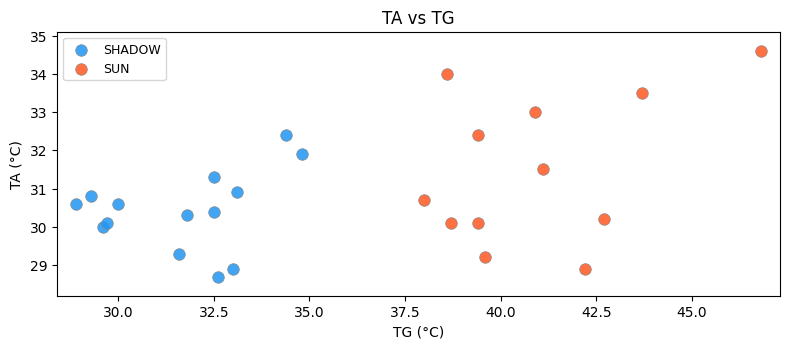

In [140]:
df = points_proj.copy().reset_index(drop=True)


colors = {"SHADOW": "#2196F3", "SUN": "#FF5722"}

fig, ax = plt.subplots(figsize=(8, 7))

for cond, group in df.groupby("condition"):
    ax.scatter(group["TG"], group["TA"],
               color=colors.get(cond, "gray"), s=70, zorder=3,
               edgecolors="gray", linewidths=0.5, label=cond, alpha=0.85)

ax.set_xlim(df["TG"].min() - 0.5, df["TG"].max() + 0.5)
ax.set_ylim(df["TA"].min() - 0.5, df["TA"].max() + 0.5)
ax.set_aspect("equal")

ax.set_xlabel("TG (°C)")
ax.set_ylabel("TA (°C)")
ax.set_title("TA vs TG", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

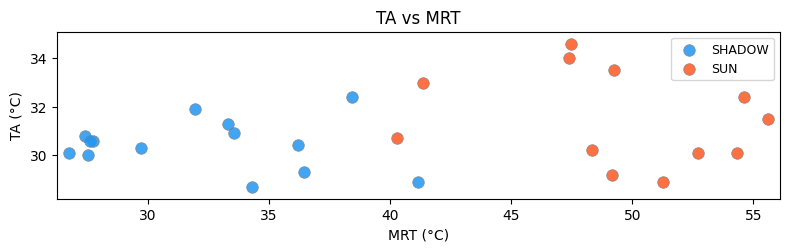

In [141]:


colors = {"SHADOW": "#2196F3", "SUN": "#FF5722"}

fig, ax = plt.subplots(figsize=(8, 7))

for cond, group in df.groupby("condition"):
    ax.scatter(group["MRT"], group["TA"],
               color=colors.get(cond, "gray"), s=70, zorder=3,
               edgecolors="gray", linewidths=0.5, label=cond, alpha=0.85)

ax.set_xlim(df["MRT"].min() - 0.5, df["MRT"].max() + 0.5)
ax.set_ylim(df["TA"].min() - 0.5, df["TA"].max() + 0.5)
ax.set_aspect("equal")

ax.set_xlabel("MRT (°C)")
ax.set_ylabel("TA (°C)")
ax.set_title("TA vs MRT", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

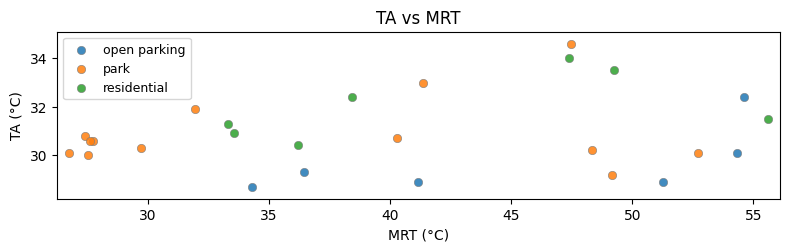

In [142]:
fig, ax = plt.subplots(figsize=(8, 7))

for cond, group in df.groupby("context"):
    ax.scatter(group["MRT"], group["TA"],
               edgecolors="gray", linewidths=0.5, label=cond, alpha=0.85)

ax.set_xlim(df["MRT"].min() - 0.5, df["MRT"].max() + 0.5)
ax.set_ylim(df["TA"].min() - 0.5, df["TA"].max() + 0.5)
ax.set_aspect("equal")

ax.set_xlabel("MRT (°C)")
ax.set_ylabel("TA (°C)")
ax.set_title("TA vs MRT", fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()